# 실습 주제: PyTorch로 CBOW 및 Skip-Gram 구현하기

# Implementing Word2Vec Models using Pytorch
본 실습 수업은 PubMed/PMC로부터 수집한 코퍼스를 전처리해 **CBOW(Continuous Bag-of-Words)** 학습 데이터로 만들고, `nn.EmbeddingBag`을 활용한 간단한 Word2Vec-CBOW 모델을 PyTorch로 구현, 학습 및 시각화하는 과정을 다룹니다.

## Key Implementation Points

### From Pubmed Corpus to CBOW Data Module
1. Data Acquisition
   - NCBI PMC OA Bulk의 증분 아카이브(`oa_comm_xml.incr.YYYYMMDD.tar.gz`)를 날짜 구간으로 다운로드합니다.
   - 압축 해제 후 `PMC*` 폴더의 `.xml` 파일을 하나의 디렉터리로 모아 정리합니다.
   - JATS XML 파서를 사용하여 `pmcid`, `title`, `abstract` 등의 텍스트 필드를 추출합니다.

2. Data Preprocessing
    - 텍스트 정규화(소문자화, 특수기호 처리, 공백 정리).
    - 문장/단어 단위 토큰화 후 lemmas(어간/표제어) 리스트 생성 → df['lemmas']에 저장.
    - 어휘 사전(vocab) 구축: 최소 빈도(min_freq) 적용, `<pad>`, `<unk>` 등 특수 토큰 추가.
   - CBOW 샘플 생성: 윈도우 크기 `w`에 대해
      - 입력(context): 좌우 `w`개 토큰 인덱스
      - 타깃(target): 중심 토큰 인덱스
    - Train/Valid/Test를 문서 단위로 분할한 뒤 각 split에서 샘플을 생성합니다.

3. Data Module Implementation
    - `Dataset`: 항목별 `(context_indices, target_index)` 반환(딕셔너리 `{X, y}` 권장)  
    - `collate_fn`: CBOW는 컨텍스트 길이 고정(2*w) → 패딩 불필요 (`X=(B,2w)`, `y=(B,)`)  
    - `DataLoader`: Train은 `shuffle=True`, Valid/Test는 `False`; `num_workers`로 속도 조정  
    - 학습 후 분석을 위해 `stoi/itos`, `vocab_size`를 보존

### Building Blocks for the CBOW Model
-  **nn.Linear**
    - 역할: 문맥 임베딩의 집계 표현(평균 등)을 중심 단어 분류 점수(logits)로 사상  
    - 입·출력: `(B, D) → (B, V)` (D=임베딩 차원, V=어휘 크기)  
    - `CrossEntropyLoss` 사용 시 출력에 소프트맥스는 적용하지 않음  
    - [PyTorch 설명](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)
-  **nn.Dropout**
    - 역할: 직전 layer로부터 산출된 tensor의 원소 중 무작위로 0으로 만들어 overfitting 방지  
    - 위치: `Embedding/EmbeddingBag` 출력 뒤, `Linear` 앞에 배치하는 것이 일반적  
    - `model.train()`에서만 활성, `eval()`에서는 비활성  
    - [PyTorch 설명](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
-  **nn.Embedding**
    - 역할: 토큰 인덱스를 연속 벡터 공간의 임베딩으로 매핑  
    - 입·출력: `(B, T) → (B, T, D)`  
    - CBOW에서 직접 평균을 구현할 수도 있으나, 다건 인덱스를 평균/합으로 효율 집계하는 **EmbeddingBag**이 더 적합  
    - [PyTorch 설명](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html)
-  **nn.EmbeddingBag**
    - 역할: 여러 인덱스(“bag”)의 임베딩을 **평균/합**으로 한 번에 집계 → CBOW 문맥 평균에 적합  
    - 사용: 평평하게 펴진 인덱스 벡터와 각 샘플의 시작 `offsets` 전달 → 출력은 `(B, D)`  
    - 장점: 패딩/마스크/루프 없이 문맥 집계를 고속 처리  
    - [PyTorch 설명](https://docs.pytorch.org/docs/stable/generated/torch.nn.EmbeddingBag.html)
    

### 필요한 라이브러리를 설치합니다.

In [ ]:
!pip -q install nltk scikit-learn wordcloud

### 파이썬 라이브러리를 Import합니다.

In [ ]:
from datetime import datetime, timedelta
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
import glob
import shutil
from pathlib import Path
from tqdm import tqdm
import pandas as pd
from datetime import timedelta, datetime
import xml.etree.ElementTree as ET
import re, math, unicodedata
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## STEP 1: Data Preparation

### 텍스트 전처리를 하기 위한 준비를 합니다.

In [ ]:
# 도메인 보강 불용어 (필요 시 조정)
BIO_STOPWORDS = {
    "et", "al", "using", "based", "however", "therefore", "result", "results",
    "method", "methods", "conclusion", "conclusions", "background", "objective", "objectives",
    "introduction", "aim", "aims", "purpose", "materials", "patients", "study", "studies"
}

# 그리스 문자/단위 기호 치환 테이블
_GREEK_MAP = {
    "α":"alpha","β":"beta","γ":"gamma","δ":"delta","ε":"epsilon","κ":"kappa","μ":"micro","π":"pi",
    "ω":"omega","λ":"lambda","θ":"theta","σ":"sigma","τ":"tau","Δ":"delta","Σ":"sigma","Ω":"omega","µ":"micro"
}
_TRANS_TABLE = str.maketrans(_GREEK_MAP)

# 토큰 보존 규칙: 알파벳/숫자 시작, 하이픈 허용(IL-6, covid-19), 너무 짧은 토큰 제거(길이<2)
_BIO_TOKEN_RE = re.compile(r"^[A-Za-z0-9][A-Za-z0-9\-]*$")

# 전역 자원
_STOP = set(stopwords.words("english")) | BIO_STOPWORDS
_STEM = PorterStemmer()
_LEM  = WordNetLemmatizer()

### 본격적으로 PubMed Corpus를 관리하기 쉬운 형태의 DataFrame으로 변환합니다.

In [ ]:
def load_corpus_to_dataframe(start_date, end_date):
    # ---------------------------
    # 날짜 리스트 만들기
    # ---------------------------
    list_dates = []
    current_date = start_date
    # datetime이면 date로 변환
    if isinstance(current_date, datetime):
        current_date = current_date.date()
    if isinstance(end_date, datetime):
        end_date = end_date.date()

    while current_date <= end_date:
        list_dates.append(current_date)
        current_date += timedelta(days=1)

    # URL용(YYYYMMDD) / 출력용(YYYY-MM-DD) 포맷 모두 준비
    list_dates_str_ftp = [d.strftime("%Y-%m-%d") for d in list_dates]
    list_dates_str_print = [d.strftime("%Y-%m-%d") for d in list_dates]

    # ---------------------------
    # 날짜별 증분패키지 처리 함수 (원래 흐름 유지: wget/tar/rm)
    # ---------------------------
    def process_dataset(dataset_date_str):
        ftp_path = f"https://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_bulk/oa_comm/xml/oa_comm_xml.incr.{dataset_date_str}.tar.gz"

        # Download
        command = ["wget", "-O", f"pubmed_{dataset_date_str}.tar.gz", ftp_path]
        subprocess.run(command, check=True)

        # Extract
        command = ["tar", "-xzf", f"pubmed_{dataset_date_str}.tar.gz"]
        subprocess.run(command, check=True)

        # Clean up
        command = ["rm", f"pubmed_{dataset_date_str}.tar.gz"]
        subprocess.run(command, check=True)

        return dataset_date_str

    # ---------------------------
    # 병렬 다운로드/압축해제
    # ---------------------------
    max_workers = 32  # 시스템/대역폭에 맞게 조정
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_dataset, ds) for ds in list_dates_str_ftp]
        for future in as_completed(futures):
            try:
                _ = future.result()
            except Exception as e:
                print(f"Error processing dataset: {e}")

    # ---------------------------
    # PMC 폴더 파일 수 요약 (원래 로직 유지)
    # ---------------------------
    pmc_folders = glob.glob("PMC0*")
    total_files = 0
    for folder in pmc_folders:
        if os.path.isdir(folder):
            file_count = len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])
            print(f"{folder}: {file_count} files")
            total_files += file_count

    # ---------------------------
    # 목적지 폴더 생성 및 XML 이동 (원래 로직 유지하되 이름충돌만 방지)
    # ---------------------------
    destination = "recent_pubmed"
    os.makedirs(destination, exist_ok=True)

    # Find all PMC* folders (조금 포괄적으로)
    pmc_folders = [d for d in os.listdir('.') if d.startswith('PMC') and os.path.isdir(d)]

    def _unique_dest_path(dst_dir: str, fname: str) -> str:
        base = os.path.splitext(fname)[0]
        ext = os.path.splitext(fname)[1]
        candidate = os.path.join(dst_dir, fname)
        idx = 1
        while os.path.exists(candidate):
            candidate = os.path.join(dst_dir, f"{base}__{idx}{ext}")
            idx += 1
        return candidate

    moved_count = 0
    for folder in pmc_folders:
        folder_path = Path(folder)
        xml_files = folder_path.glob("*.xml")
        for xml_file in tqdm(xml_files, desc=f"Move from {folder}"):
            try:
                target = _unique_dest_path(destination, xml_file.name)
                shutil.move(str(xml_file), target)
                moved_count += 1
            except Exception as e:
                print(f"Error moving {xml_file}: {e}")

    # ---------------------------
    # XML 파싱 함수(기존 함수 있으면 사용, 없으면 기본 파서)
    # ---------------------------
    def _clean_ws(text: str) -> str:
        """여러 공백/개행을 하나로 정리."""
        return " ".join((text or "").split())

    def _default_parse_pmc_title_abstract(xml_path: str):
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            def _txt(e):
                return "".join(e.itertext()).strip() if e is not None else ""

            # pmcid
            pmcid = None
            pmid = None
            for aid in root.findall(".//article-meta/article-id"):
                _type = (aid.get("pub-id-type") or "").lower()
                if _type == "pmc":
                    pmcid = _clean_ws(aid.text)
                elif _type == "pmid":
                    pmid = _clean_ws(aid.text)

            # title
            title_el = root.find(".//article-title")
            title = _txt(title_el) if title_el is not None else None

            # abstracts (여러 개면 합침)
            abs_list = []
            for ab in root.findall(".//abstract"):
                t = _txt(ab)
                if t:
                    abs_list.append(t)
            abstract = "\n\n".join(abs_list) if abs_list else None

            return {"pmcid": pmcid, "title": title, "abstract": abstract, "path": xml_path, "pmid": pmid}
        except Exception as e:
            print(f"[WARN] parse failed: {xml_path} -> {e}")
            return None

    # 바깥에 동일 이름 함수가 있으면 사용
    parse_func = globals().get("parse_pmc_title_abstract", _default_parse_pmc_title_abstract)

    def process_xml_file(xml_file):
        xml_path = os.path.join('./recent_pubmed', xml_file)
        if os.path.isfile(xml_path):
            return parse_func(xml_path)
        return None

    # ---------------------------
    # recent_pubmed 내 XML 병렬 파싱 (원래 로직 유지)
    # ---------------------------
    xml_files = [f for f in os.listdir('./recent_pubmed')
                 if os.path.isfile(os.path.join('./recent_pubmed', f)) and f.lower().endswith(".xml")]

    list_records = []
    max_workers = 32  # 시스템에 맞게 조정

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_file = {executor.submit(process_xml_file, xml_file): xml_file for xml_file in xml_files}
        for future in as_completed(future_to_file):
            xml_file = future_to_file[future]
            try:
                result = future.result()
                if result is not None:
                    list_records.append(result)
            except Exception as e:
                print(f"Error processing {xml_file}: {e}")

    df = pd.DataFrame(list_records)
    # 편의를 위해 누락 컬럼 보정
    for col in ["pmcid", "title", "abstract", "path"]:
        if col not in df.columns:
            df[col] = None
    return df


### 수집할 PubMed 말뭉치 데이터의 기간을 지정하여 데이터 수집을 수행합니다.

In [ ]:
start_date = datetime(2025, 9, 1)
end_date = datetime(2025, 9, 10)
df = load_corpus_to_dataframe(start_date, end_date)
df

PMC011xxxxxx: 348 files
PMC009xxxxxx: 19 files
PMC012xxxxxx: 10811 files
PMC007xxxxxx: 39 files
PMC006xxxxxx: 1 files
PMC008xxxxxx: 9 files
PMC005xxxxxx: 3 files
PMC010xxxxxx: 54 files


Move from PMC011xxxxxx: 348it [00:00, 11046.83it/s]
Move from PMC009xxxxxx: 19it [00:00, 6408.67it/s]
Move from PMC012xxxxxx: 10811it [00:01, 6714.59it/s]
Move from PMC007xxxxxx: 39it [00:00, 9632.99it/s]
Move from PMC006xxxxxx: 1it [00:00, 2597.09it/s]
Move from PMC008xxxxxx: 9it [00:00, 15637.42it/s]
Move from PMC005xxxxxx: 3it [00:00, 10745.44it/s]
Move from PMC010xxxxxx: 54it [00:00, 9353.39it/s]


,pmcid,title,abstract,path,pmid
0,PMC12406194,A Data-Driven Perspective\non Bioisostere Eval...,The bioisostere landscape\nis continually expa...,./recent_pubmed/PMC12406194.xml,40763221
1,PMC12262410,Valve endothelial monolayer fissuring via RhoA...,AbstractCalcific aortic valve disease (CAVD) i...,./recent_pubmed/PMC12262410.xml,40666953
2,PMC12406264,The cleavage of indinavir sulfate: synthesis a...,The cleavage of the HIV-1 protease inhibitor i...,./recent_pubmed/PMC12406264.xml,40762275
3,PMC12410115,Factors Influencing Clinical Competence Among ...,AbstractObjective. This study aimed to investi...,./recent_pubmed/PMC12410115.xml,None
4,PMC12412558,Spontaneous Strain‐Spin Transition Coupling Mo...,AbstractMaterials that exhibit controllable ch...,./recent_pubmed/PMC12412558.xml,40464589
...,...,...,...,...,...
11279,PMC12413595,Current use of mechanical bowel preparation an...,None,./recent_pubmed/PMC12413595.xml,40040509
11280,PMC11639609,Prevotellaceae Modulates Colorectal Cancer Imm...,Background/Aims:Colorectal cancer (CRC) stands...,./recent_pubmed/PMC11639609.xml,39641253
11281,PMC12407228,Neurogenic Voiding Dysfunction in Spinal Cord ...,Many patients with injuries to their central n...,./recent_pubmed/PMC12407228.xml,None
11282,PMC12397073,Palaeohistology and life history of the early ...,AbstractThe life histories of Palaeocene mamma...,./recent_pubmed/PMC12397073.xml,40657952


### 말뭉치 데이터를 전처리합니다 (병렬처리 활용)

In [ ]:
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

# 워커 전역(프로세스별) 초기화용
_WORKER_STOP = None
_WORKER_STEM = None
_WORKER_LEM  = None

def _init_worker(stop_words_list):
    # 각 워커에서 전역 재설정 (피클링 안전)
    global _WORKER_STOP, _WORKER_STEM, _WORKER_LEM
    _WORKER_STOP = set(stop_words_list)
    _WORKER_STEM = PorterStemmer()
    _WORKER_LEM  = WordNetLemmatizer()

def _worker_preprocess(text: str) -> dict:
    # 단일 텍스트 처리 (워커 전역 사용)
    s = (text or "").strip()
    s = unicodedata.normalize("NFKC", s).translate(_TRANS_TABLE)
    s = re.sub(r"http\S+|www\.\S+", " ", s).lower()
    toks = word_tokenize(s)
    toks = [t for t in toks if _BIO_TOKEN_RE.match(t)]
    toks_no_stop = [t for t in toks if t not in _WORKER_STOP and len(t) >= 2]
    stems  = [_WORKER_STEM.stem(t) for t in toks_no_stop]
    lemmas = [_WORKER_LEM.lemmatize(t) for t in toks_no_stop]
    return {
        "tokens": toks,
        "tokens_no_stop": toks_no_stop,
        "stems": stems,
        "lemmas": lemmas,
    }

def preprocess_df_parallel(df: pd.DataFrame, n_jobs: int = None, chunksize: int = 1000) -> pd.DataFrame:
    """
    큰 DF 병렬 전처리:
      - df를 row 청크로 나눠 multiprocess 처리
      - 원래 인덱스 순서 보존
    """
    if n_jobs is None:
        n_jobs = max(1, mp.cpu_count() - 1)

    # 청크 분할
    idx = df.index.to_list()
    chunks = [idx[i:i+chunksize] for i in range(0, len(idx), chunksize)]

    # 결과 담을 컨테이너
    results = {}

    with ProcessPoolExecutor(
        max_workers=n_jobs,
        initializer=_init_worker,
        initargs=(list(_STOP),)  # 메인에서 만든 불용어 집합 전달
    ) as ex:
        for chunk_idx in chunks:
            abstracts = df.loc[chunk_idx, "abstract"].astype(str).tolist()
            # 병렬 map
            outs = list(ex.map(_worker_preprocess, abstracts))
            for k, row_id in enumerate(chunk_idx):
                results[row_id] = outs[k]

    # 출력 DF 구성
    out = df.copy()
    out["tokens"]          = pd.Series({k: v["tokens"] for k, v in results.items()})
    out["tokens_no_stop"]  = pd.Series({k: v["tokens_no_stop"] for k, v in results.items()})
    out["stems"]           = pd.Series({k: v["stems"] for k, v in results.items()})
    out["lemmas"]          = pd.Series({k: v["lemmas"] for k, v in results.items()})
    out["n_tokens"]        = out["tokens"].apply(len)
    out["n_tokens_nostop"] = out["tokens_no_stop"].apply(len)
    return out

# 사용 예시
df_preprocessed = preprocess_df_parallel(df, n_jobs=25, chunksize=5000)
df_preprocessed = df_preprocessed.set_index('pmcid')
df_preprocessed

,title,abstract,path,pmid,tokens,tokens_no_stop,stems,lemmas,n_tokens,n_tokens_nostop
pmcid,,,,,,,,,,
PMC12406194,A Data-Driven Perspective\non Bioisostere Eval...,The bioisostere landscape\nis continually expa...,./recent_pubmed/PMC12406194.xml,40763221,"[the, bioisostere, landscape, is, continually,...","[bioisostere, landscape, continually, expandin...","[bioisoster, landscap, continu, expand, new, s...","[bioisostere, landscape, continually, expandin...",129,80
PMC12262410,Valve endothelial monolayer fissuring via RhoA...,AbstractCalcific aortic valve disease (CAVD) i...,./recent_pubmed/PMC12262410.xml,40666953,"[abstractcalcific, aortic, valve, disease, cav...","[abstractcalcific, aortic, valve, disease, cav...","[abstractcalcif, aortic, valv, diseas, cavd, d...","[abstractcalcific, aortic, valve, disease, cav...",242,150
PMC12406264,The cleavage of indinavir sulfate: synthesis a...,The cleavage of the HIV-1 protease inhibitor i...,./recent_pubmed/PMC12406264.xml,40762275,"[the, cleavage, of, the, hiv-1, protease, inhi...","[cleavage, hiv-1, protease, inhibitor, indinav...","[cleavag, hiv-1, proteas, inhibitor, indinavir...","[cleavage, hiv-1, protease, inhibitor, indinav...",177,119
PMC12410115,Factors Influencing Clinical Competence Among ...,AbstractObjective. This study aimed to investi...,./recent_pubmed/PMC12410115.xml,None,"[abstractobjective, this, study, aimed, to, in...","[abstractobjective, aimed, investigate, emotio...","[abstractobject, aim, investig, emot, intellig...","[abstractobjective, aimed, investigate, emotio...",162,119
PMC12412558,Spontaneous Strain‐Spin Transition Coupling Mo...,AbstractMaterials that exhibit controllable ch...,./recent_pubmed/PMC12412558.xml,40464589,"[abstractmaterials, that, exhibit, controllabl...","[abstractmaterials, exhibit, controllable, cha...","[abstractmateri, exhibit, control, chang, elec...","[abstractmaterials, exhibit, controllable, cha...",167,113
...,...,...,...,...,...,...,...,...,...,...
PMC12413595,Current use of mechanical bowel preparation an...,None,./recent_pubmed/PMC12413595.xml,40040509,[none],[none],[none],[none],1,1
PMC11639609,Prevotellaceae Modulates Colorectal Cancer Imm...,Background/Aims:Colorectal cancer (CRC) stands...,./recent_pubmed/PMC11639609.xml,39641253,"[colorectal, cancer, crc, stands, as, the, thi...","[colorectal, cancer, crc, stands, third, preva...","[colorect, cancer, crc, stand, third, preval, ...","[colorectal, cancer, crc, stand, third, preval...",273,173
PMC12407228,Neurogenic Voiding Dysfunction in Spinal Cord ...,Many patients with injuries to their central n...,./recent_pubmed/PMC12407228.xml,None,"[many, patients, with, injuries, to, their, ce...","[many, injuries, central, nervous, system, esp...","[mani, injuri, central, nervou, system, especi...","[many, injury, central, nervous, system, espec...",257,147


# Step 2. PyTorch Implementation

## PyTorch Dataset 클래스를 생성하기 위한 필요한 유틸 함수를 구현합니다.

In [ ]:
import os
import math
import random
from typing import List, Dict, Tuple
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# =========================
# 1) Vocab 생성 유틸
# =========================
PAD, UNK = "<pad>", "<unk>"
SPECIALS = [PAD, UNK]

def build_vocab_from_lemmas(df: pd.DataFrame, min_freq: int = 1, max_vocab: int = None) -> Tuple[Dict[str, int], Dict[int, str]]:
    """
    df['lemmas'] : List[str]
    """
    from collections import Counter
    cnt = Counter()
    for toks in df["lemmas"]:
        if toks is None:
            continue
        for t in toks:
            cnt[t] += 1

    # 빈도 필터
    items = [(tok, f) for tok, f in cnt.items() if f >= min_freq]
    # 빈도순 정렬
    items.sort(key=lambda x: (-x[1], x[0]))

    if max_vocab is not None:
        items = items[:max_vocab - len(SPECIALS)]

    itos = SPECIALS + [tok for tok, _ in items]  # index -> token
    stoi = {tok: idx for idx, tok in enumerate(itos)}  # token -> index
    return stoi, {i: t for i, t in enumerate(itos)}

def tokens_to_indices(tokens: List[str], stoi: Dict[str, int]) -> List[int]:
    unk_idx = stoi[UNK]
    return [stoi.get(t, unk_idx) for t in tokens]

## CBOW 모델에 특화된 Dataset 클래스를 구현합니다.

In [ ]:
# =========================
# 2) CBOW Dataset
# =========================
class CBOWDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        stoi: Dict[str, int],
        window_size: int = 2,
        max_samples_per_doc: int = None,
        device='cpu'):
        """
        df['lemmas'] : List[str]
        window_size: 좌/우 문맥 크기 (총 context 길이는 2*window_size)
        max_samples_per_doc: 문서당 샘플 최대 개수(크면 메모리 절약용 다운샘플링)
        """
        super().__init__()
        self.stoi = stoi
        self.window_size = window_size
        self.samples: List[Tuple[List[int], int]] = []  # (context_indices, target_idx)
        self.device = device

        for _, row in df.iterrows():
            toks = row.get("lemmas", None)
            if toks is None or not isinstance(toks, list) or len(toks) < 2*window_size + 1:
                continue

            ids = tokens_to_indices(toks, self.stoi)
            local_samples = []

            for i in range(window_size, len(ids) - window_size):
                target = ids[i]
                left_ctx = ids[i - window_size:i]
                right_ctx = ids[i + 1:i + 1 + window_size]
                context = left_ctx + right_ctx
                local_samples.append((context, target))

            if max_samples_per_doc is not None and len(local_samples) > max_samples_per_doc:
                local_samples = random.sample(local_samples, max_samples_per_doc)

            self.samples.extend(local_samples)

        random.shuffle(self.samples)

    def to(self, device_type):
        self.device = device_type

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        context, target = self.samples[idx]
        return dict(X=torch.tensor(context, dtype=torch.long).to(self.device),
                    y=torch.tensor(target, dtype=torch.long).to(self.device))

In [ ]:
stoi, itos = build_vocab_from_lemmas(df_preprocessed, min_freq=1, max_vocab=10000)
dataset    = CBOWDataset(df_preprocessed, stoi)
print(len(dataset))

1586016


In [ ]:
idx = 10000
print("Tensor Dict", dataset[idx])
print("")
print("Input Bag of Words")
for i in dataset[idx]['X'].cpu().numpy().tolist():
    print(itos[i])
print("")
print("Ouput Target Word")
print(itos[dataset[idx]['y'].item()])

Tensor Dict {'X': tensor([  5,   8, 763, 162]), 'y': tensor(6)}

Input Bag of Words
group
clinical
ct
feature

Ouput Target Word
data


## CBOW 모델에 특화된 데이터 관리 모듈을 구현합니다.

In [ ]:
# =========================
# 4) CBOW Data Module
# =========================
class LemmaCBOWDataModule(object):
    def __init__(
        self,
        df_all:              pd.DataFrame,
        batch_size:          int   = 256,
        window_size:         int   = 2,
        min_freq:            int   = 1,
        max_vocab:           int   = None,
        max_samples_per_doc: int   = None,
        test_size:           float = 0.1,
        valid_size:          float = 0.05,
        seed:                int   = 42,
        device:              str   = 'cpu'
        ):

        # vocab build
        self.stoi, self.itos = build_vocab_from_lemmas(df_all, min_freq=min_freq, max_vocab=max_vocab)
        self.vocab_size = len(self.stoi)

        # 문서 단위로 분할 (pmcid 인덱스 유지 시 stratify 불가 → 랜덤 split)
        idx_all = df_all.index
        train_idx, test_idx = train_test_split(idx_all, test_size=test_size, random_state=seed)
        train_idx, valid_idx = train_test_split(train_idx, test_size=valid_size, random_state=seed)

        df_train = df_all.loc[train_idx].reset_index(drop=True)
        df_valid = df_all.loc[valid_idx].reset_index(drop=True)
        df_test  = df_all.loc[test_idx].reset_index(drop=True)

        self.train_dataset = CBOWDataset(df_train, self.stoi, window_size, max_samples_per_doc)
        self.valid_dataset = CBOWDataset(df_valid, self.stoi, window_size, max_samples_per_doc)
        self.test_dataset  = CBOWDataset(df_test,  self.stoi, window_size, max_samples_per_doc)

        self.train_dataset.to(device)
        self.valid_dataset.to(device)
        self.test_dataset.to(device)

        self.batch_size = batch_size
        self.window_size = window_size

        print(f"Vocab size: {self.vocab_size}")
        print(f"#Train samples: {len(self.train_dataset)}")
        print(f"#Valid samples: {len(self.valid_dataset)}")
        print(f"#Test  samples: {len(self.test_dataset)}")

    @staticmethod
    def collate_fn(batch):
        # CBOW는 문맥 길이가 고정(2*window) → 패딩 불필요
        X = torch.stack([b['X'] for b in batch], dim=0)  # (B, 2*window)
        y = torch.stack([b['y'] for b in batch], dim=0)  # (B,)
        return dict(X=X, y=y)

    def get_train_loader(self): return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True,  collate_fn=self.collate_fn)
    def get_valid_loader(self): return DataLoader(self.valid_dataset, batch_size=self.batch_size, shuffle=False, collate_fn=self.collate_fn)
    def get_test_loader (self): return DataLoader(self.test_dataset,  batch_size=self.batch_size, shuffle=False, collate_fn=self.collate_fn)


In [ ]:
datamodule = LemmaCBOWDataModule(df_preprocessed)

for train_batch in datamodule.get_train_loader():
    print(train_batch['X'].shape)
    print(train_batch['y'].shape)
    break

Vocab size: 82130
#Train samples: 1321399
#Valid samples: 71713
#Test  samples: 192904
torch.Size([256, 4])
torch.Size([256])


## 본격적으로 CBOW 모델을 구현합니다.

In [ ]:
# =========================
# 4) CBOW 모델 (EmbeddingBag 사용)
# =========================
class CBOW(nn.Module):
    def __init__(
        self,
        vocab_size:  int,
        embed_dim:   int = 128,
        padding_idx: int = 0,
        dropout_p:   float = 0.2,
        ):
        super().__init__()
        # EmbeddingBag: 여러 인덱스 임베딩을 평균/합산 → CBOW 평균에 적합
        self.emb = nn.EmbeddingBag(vocab_size, embed_dim, mode='mean', padding_idx=padding_idx)
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(embed_dim, vocab_size)  # center word 분류
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, pt_batch):
        X = pt_batch['X']
        y = pt_batch['y']

        B, C = X.shape
        flat = X.reshape(-1)
        offsets = torch.arange(0, B*C, step=C, device=X.device, dtype=torch.long)

        h = self.emb(flat, offsets)
        h = self.dropout(h)
        logits = self.fc(h)

        loss = self.criterion(logits, y)
        pt_batch['logits'] = logits
        pt_batch['loss'] = loss
        return pt_batch


In [ ]:
datamodule = LemmaCBOWDataModule(df_preprocessed, device='cpu')
model      = CBOW(vocab_size=datamodule.vocab_size).to('cpu')

for train_batch in datamodule.get_train_loader():
    output = model(train_batch)
    print(output['loss'])
    print(output['logits'])
    print(output['logits'].shape)
    print(output['logits'].argmax(1))
    print(output['logits'].argmax(1).shape)
    break

Vocab size: 82130
#Train samples: 1321399
#Valid samples: 71713
#Test  samples: 192904
tensor(11.3823, grad_fn=<NllLossBackward0>)
tensor([[-0.0405,  0.2772, -0.2823,  ..., -0.1665,  0.4277,  0.3833],
        [ 0.0785, -0.7182,  0.1696,  ...,  0.1234,  0.2236,  0.1008],
        [-0.2990, -0.0663,  0.6954,  ...,  0.2713,  0.6734,  0.1679],
        ...,
        [-0.0230,  0.1528, -0.5697,  ...,  0.5398,  0.0061,  0.4688],
        [-0.6261, -0.1915,  0.1392,  ...,  0.2086,  0.0497,  0.1861],
        [ 0.6920, -0.2409, -0.0975,  ...,  0.5407, -0.2940, -0.0621]],
       grad_fn=<AddmmBackward0>)
torch.Size([256, 82130])
tensor([ 9509, 49630,  8460, 32435, 82004, 66404,  3377,  9128, 35656, 14400,
        18588, 78076, 19648, 25064, 82122, 57566, 74270, 57284,  5483, 80057,
        40205, 32856, 14117, 37574,  1067, 15712,  9907, 59715, 70316,  6311,
        67258,  9818, 55413, 77373, 77814,  8313, 58116, 70491, 49826, 50970,
        63526, 19142, 59465, 79579, 64345, 45452, 30199, 16434,  

## 구현한 CBOW 모델을 학습시키기 위한 Trainer 클래스를 정의합니다.

In [ ]:
# =========================
# 5) Word2Vec Trainer
# =========================
import torch
from torch import nn, optim
from tqdm import tqdm
import matplotlib.pyplot as plt


class Word2VecTrainer(object):
    """
    Word2Vec 학습/검증/테스트 Trainer
    - CrossEntropyLoss 기반 missing word를 예측합니다 (classification)
    - 에폭별 손실/정확도 기록 및 시각화
    """
    def __init__(
        self,
        learning_rate: float = 2e-3,
        weight_decay:  float = 1e-5,
        num_epochs:    int   = 5,
        device:        str   = 'cuda' if torch.cuda.is_available() else 'cpu'
    ):
        self.learning_rate = learning_rate
        self.weight_decay  = weight_decay
        self.num_epochs    = num_epochs
        self.device        = device

        self.logs = {
            'train_loss':  [],
            'train_acc':   [],
            'valid_loss':  [],
            'valid_acc':   []
        }

    @staticmethod
    def _to_device_batch(pt_batch: dict, device: str) -> dict:
        """dict(batch)를 device로 이동"""
        return {k: v.to(device) if torch.is_tensor(v) else v for k, v in pt_batch.items()}

    @torch.no_grad()
    def _accuracy(self, logits: torch.Tensor, targets: torch.Tensor) -> float:
        """top-1 정확도"""
        preds = logits.argmax(dim=1)
        return (preds == targets).float().mean().item()

    def train_step(self, model: nn.Module,
                   loader: torch.utils.data.DataLoader,
                   optimizer: optim.Optimizer):
        model.train()
        running_loss, running_acc, total = 0.0, 0.0, 0

        for pt_batch in tqdm(loader, desc="  Train", leave=False):
            pt_batch = self._to_device_batch(pt_batch, self.device)

            optimizer.zero_grad(set_to_none=True)
            out = model(pt_batch)                     # {'loss', 'logits'}
            loss = out['loss']
            loss.backward()
            optimizer.step()

            B = pt_batch['X'].size(0)
            running_loss += loss.item() * B
            running_acc  += self._accuracy(out['logits'], pt_batch['y']) * B
            total        += B

        return running_loss / max(1, total), running_acc / max(1, total)

    @torch.no_grad()
    def valid_step(self, model: nn.Module,
                   loader: torch.utils.data.DataLoader):
        model.eval()
        running_loss, running_acc, total = 0.0, 0.0, 0

        for pt_batch in tqdm(loader, desc="  Valid", leave=False):
            pt_batch = self._to_device_batch(pt_batch, self.device)
            out = model(pt_batch)                     # {'loss', 'logits'}
            B = pt_batch['X'].size(0)
            running_loss += out['loss'].item() * B
            running_acc  += self._accuracy(out['logits'], pt_batch['y']) * B
            total        += B

        return running_loss / max(1, total), running_acc / max(1, total)

    def train(self, model: nn.Module,
              train_loader: torch.utils.data.DataLoader,
              valid_loader: torch.utils.data.DataLoader):
        model.to(self.device)
        optimizer = optim.AdamW(model.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)

        for epoch in range(1, self.num_epochs + 1):
            print(f"\nEpoch {epoch}/{self.num_epochs}")
            train_loss, train_acc = self.train_step(model, train_loader, optimizer)
            valid_loss, valid_acc = self.valid_step(model, valid_loader)

            print(f"  ▶ Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
            print(f"  ▶ Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

            self.logs['train_loss'].append(train_loss)
            self.logs['train_acc'].append(train_acc)
            self.logs['valid_loss'].append(valid_loss)
            self.logs['valid_acc'].append(valid_acc)

    @torch.no_grad()
    def test(self, model: nn.Module,
             test_loader: torch.utils.data.DataLoader):
        model.to(self.device)
        test_loss, test_acc = self.valid_step(model, test_loader)
        print(f"\nTest  ▶ Loss: {test_loss:.4f} | Acc: {test_acc:.4f}")
        return test_loss, test_acc

    def plot_logs(self):
        epochs = range(1, self.num_epochs + 1)
        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)
        plt.plot(epochs, self.logs['train_loss'], label='Train Loss')
        plt.plot(epochs, self.logs['valid_loss'], label='Valid Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curve'); plt.legend()

        plt.subplot(1,2,2)
        plt.plot(epochs, self.logs['train_acc'], label='Train Acc')
        plt.plot(epochs, self.logs['valid_acc'], label='Valid Acc')
        plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curve'); plt.legend()

        plt.tight_layout()
        plt.show()

## 모델 학습을 진행합니다.

Vocab size: 45050
#Train samples: 1320774
#Valid samples: 71184
#Test  samples: 153744

Epoch 1/5


  ▶ Train Loss: 8.5363 | Train Acc: 0.0386
  ▶ Valid Loss: 8.1497 | Valid Acc: 0.0534

Epoch 2/5


  ▶ Train Loss: 7.4683 | Train Acc: 0.0649
  ▶ Valid Loss: 7.8885 | Valid Acc: 0.0663

Epoch 3/5


  ▶ Train Loss: 6.9470 | Train Acc: 0.0794
  ▶ Valid Loss: 7.7918 | Valid Acc: 0.0717

Epoch 4/5


  ▶ Train Loss: 6.5831 | Train Acc: 0.0930
  ▶ Valid Loss: 7.7556 | Valid Acc: 0.0757

Epoch 5/5


  ▶ Train Loss: 6.3095 | Train Acc: 0.1058
  ▶ Valid Loss: 7.7539 | Valid Acc: 0.0787


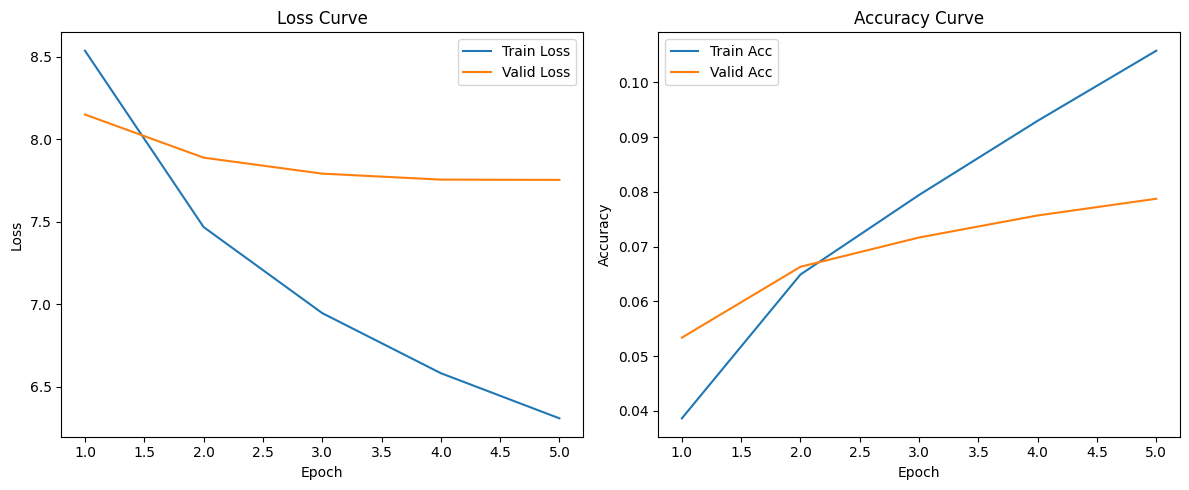


Test  ▶ Loss: 7.7240 | Acc: 0.0821


(7.724021393546379, 0.08213653866167135)

In [ ]:
# =========================
# 6) Main Execution Code Block (CBOW)
# =========================

import torch

torch.cuda.empty_cache()

# 1) 데이터 준비
# df: 반드시 df['lemmas']가 List[str] 형태로 존재해야 함 (인덱스는 pmcid 등 자유)
# 예) df = your_dataframe  # df['lemmas'] = [...]
datamodule  = LemmaCBOWDataModule(
    df_all=df_preprocessed,
    batch_size=1024,        # 문맥 윈도우가 짧으니 큰 배치도 OK
    window_size=2,          # 좌/우 2단어 문맥 → 총 4개 context
    min_freq=2,             # 희귀 토큰 제거
    max_vocab=None,         # 필요 시 상한 지정
    max_samples_per_doc=500 # 문서당 샘플 제한(메모리 절약용). 필요 없으면 None
)

trainloader = datamodule.get_train_loader()
validloader = datamodule.get_valid_loader()
testloader  = datamodule.get_test_loader()

# 2) 모델 준비
model_args = {
    'vocab_size':  datamodule.vocab_size,
    'embed_dim':   128,
    'padding_idx': 0,
    'dropout_p':   0.2,
}
model = CBOW(**model_args)

# 3) 학습 준비 (CBOWTrainer로 교체)
trainer = Word2VecTrainer(
    learning_rate=2e-3,
    weight_decay=1e-5,
    num_epochs=5,
)

# 4) 학습/검증 진행 + 로그 시각화 + 테스트
trainer.train(model, trainloader, validloader)
trainer.plot_logs()
trainer.test(model, testloader)

## 모델 정성 분석을 진행합니다.

In [ ]:
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def _ensure_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def visualize_embedding_heatmap(itos, emb_matrix, target_tokens=None, top_k=None, exclude_pad_idx=0):
    """
    A) 단어 임베딩 값 히트맵 (행=단어, 열=임베딩 차원)
    - target_tokens: 시각화할 토큰 리스트 (예: ['cell','protein','gene',...])
    - top_k: target_tokens를 주지 않으면, 사전 앞쪽에서 top_k개를 사용(패딩 제외)
    """
    E = _ensure_numpy(emb_matrix)     # (V, D)
    V, D = E.shape
    # itos: dict {idx:int -> token:str}
    stoi = {tok: idx for idx, tok in itos.items()}

    # 대상 인덱스 선택
    if target_tokens:
        idxs = [stoi[tok] for tok in target_tokens if tok in stoi]
        labels = [itos[i] for i in idxs]
    else:
        # PAD(0) 같은 특수 토큰 제외하고 상위 몇 개
        candidates = [i for i in range(V) if i != exclude_pad_idx]
        if top_k is None:
            top_k = min(30, len(candidates))
        idxs = candidates[:top_k]
        labels = [itos[i] for i in idxs]

    mat = E[idxs]  # (N, D)

    # 정규화(선택): 각 단어 벡터 z-score → 차원별 스케일 차 완화
    mat_norm = (mat - mat.mean(axis=1, keepdims=True)) / (mat.std(axis=1, keepdims=True) + 1e-8)

    df = pd.DataFrame(mat_norm, index=labels, columns=[f"d{j}" for j in range(D)])

    plt.figure(figsize=(df.shape[0]*1.1, df.shape[1]*1.1))
    sns.heatmap(df, cmap="vlag", center=0, square=True, cbar=False)
    plt.title("Word Embeddings (z-scored per word)")
    plt.xlabel("Embedding Dimension")
    plt.ylabel("Token")
    plt.tight_layout()
    plt.show()

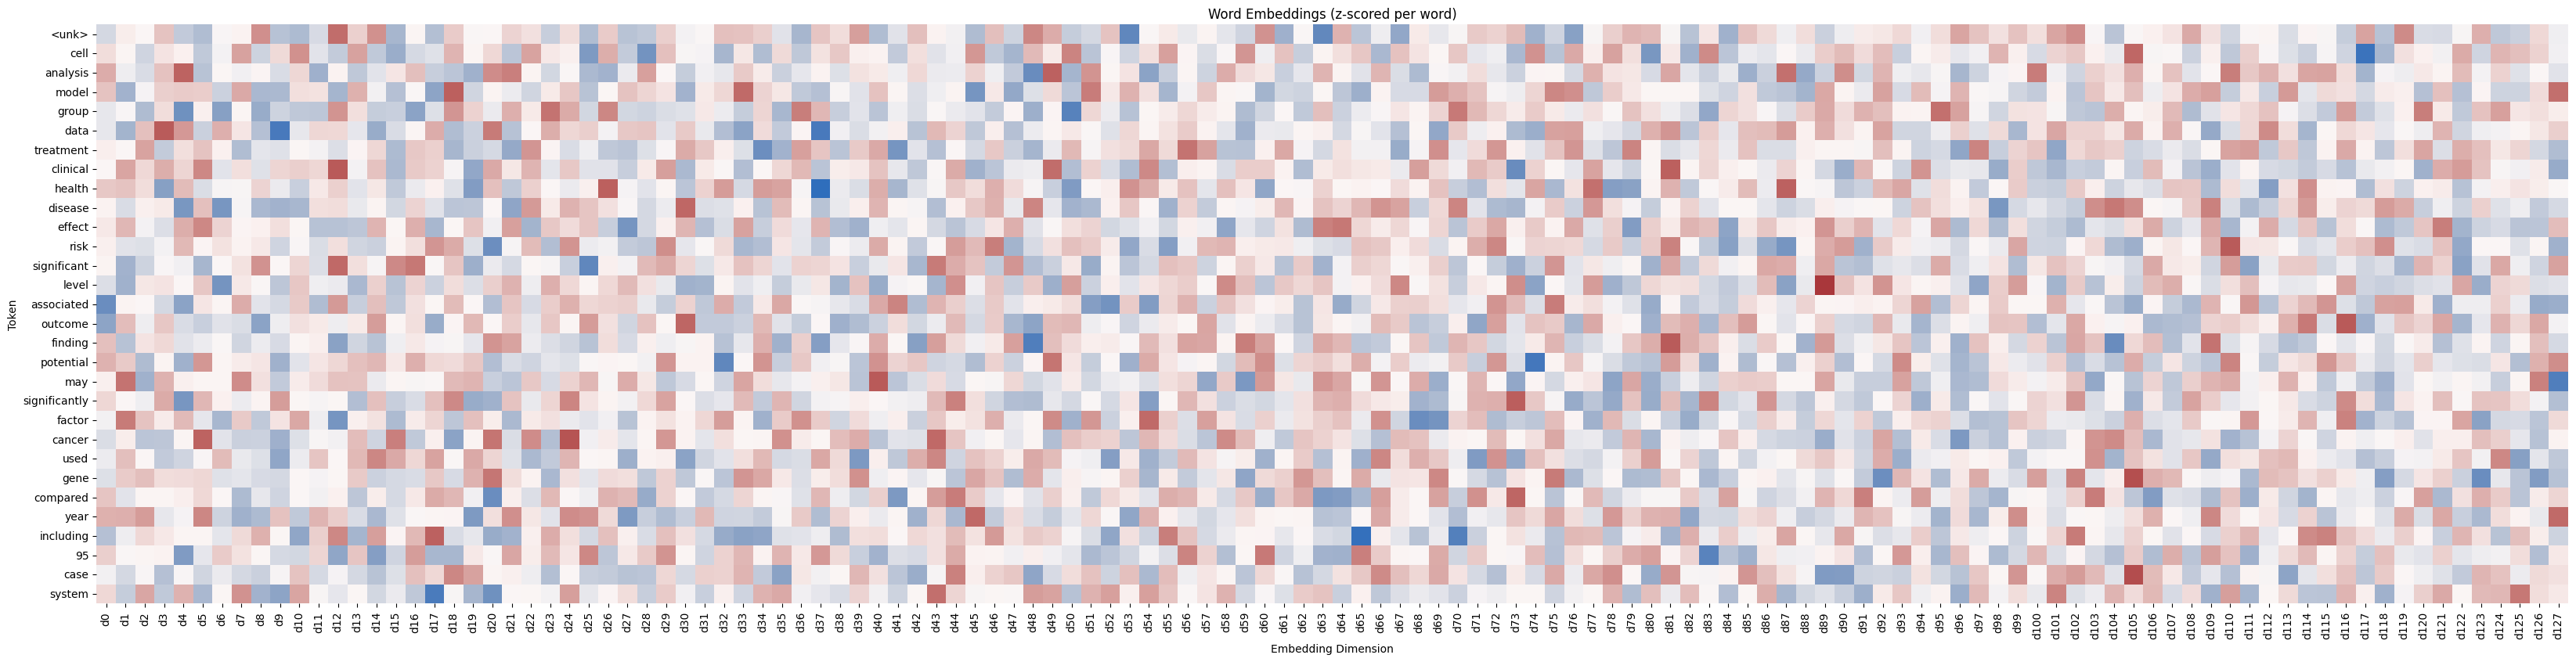

In [ ]:
emb_matrix = model.emb.weight.detach().cpu()
stoi = datamodule.stoi
itos = datamodule.itos
visualize_embedding_heatmap(itos, emb_matrix, top_k=30)


STEP 4: CBOW 모델 고급 정성 분석 시작
--- [CBOW] 학습 결과 분석 시작 ---

--- [분석 1] 최근접 이웃 단어 (Cosine Similarity) ---
  ▶ Query: 'cancer'
    1. proliferation (Sim: 0.3859)
    2. triple-negative (Sim: 0.3839)
    3. ivc (Sim: 0.3757)
    4. gbm (Sim: 0.3649)
    5. nk (Sim: 0.3646)
  ▶ Query: 'patient'
    1. 34-year-old (Sim: 0.3631)
    2. terbinafine (Sim: 0.3613)
    3. a9 (Sim: 0.3591)
    4. organon (Sim: 0.3491)
    5. attractiveness (Sim: 0.3431)
  ▶ Query: 'cell'
    1. neuropeptide (Sim: 0.3533)
    2. glia (Sim: 0.3447)
    3. initiating (Sim: 0.3391)
    4. ehd1 (Sim: 0.3390)
    5. hepatocellular (Sim: 0.3360)
  ▶ Query: 'gene'
    1. pitx2c (Sim: 0.3879)
    2. metabolite (Sim: 0.3453)
    3. fluoroalkenes (Sim: 0.3418)
    4. genome (Sim: 0.3404)
    5. oomycetes (Sim: 0.3369)
  ▶ Query: 'protein'
    1. endosomal (Sim: 0.4524)
    2. crosstalk (Sim: 0.4309)
    3. ncoa4 (Sim: 0.3953)
    4. aspn-induced (Sim: 0.3837)
    5. genotype-tissue (Sim: 0.3593)
  ▶ Query: 'dna'
    1. beta-ce

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


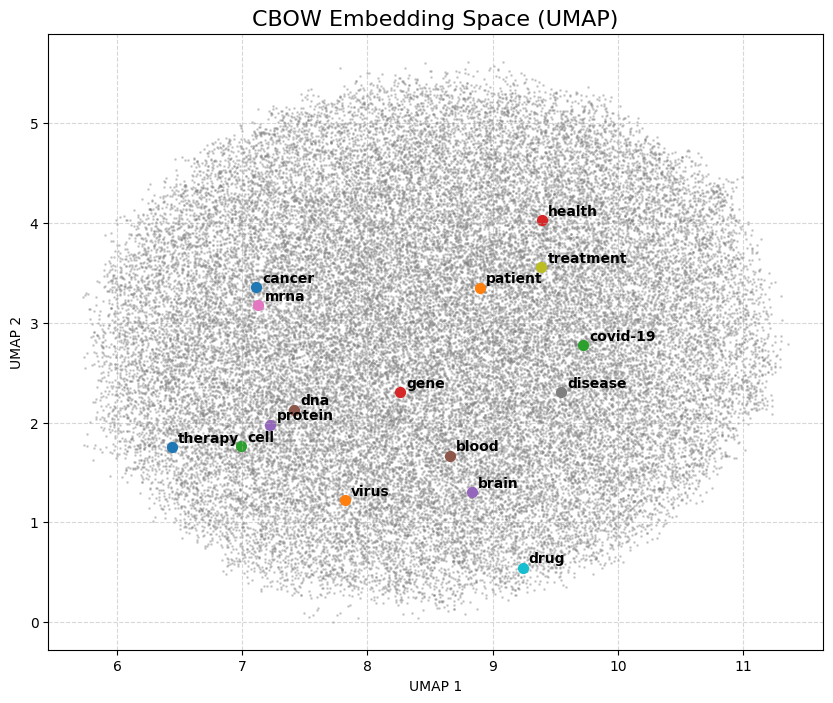


--- [분석 3] K-Means 군집화 ---

--- [분석] CBOW K-Means 군집화 (K=30) ---
K-Means (K=30) 군집화 결과 (TARGET_WORDS 위치):
  - 'cancer' 	-> Cluster 28
  - 'patient' 	-> Cluster 28
  - 'cell' 	-> Cluster 20
  - 'gene' 	-> Cluster 24
  - 'protein' 	-> Cluster 24
  - 'dna' 	-> Cluster 15
  - 'mrna' 	-> Cluster 24
  - 'disease' 	-> Cluster 28
  - 'treatment' 	-> Cluster 28
  - 'drug' 	-> Cluster 25
  - 'therapy' 	-> Cluster 25
  - 'virus' 	-> Cluster 15
  - 'covid-19' 	-> Cluster 23
  - 'health' 	-> Cluster 22
  - 'brain' 	-> Cluster 24
  - 'blood' 	-> Cluster 26

--- [분석 4] 단어 유추 (Word Analogy) ---

  ▶ Analogy: patient - disease + drug = ?
    1. tonometry (Sim: 0.3353)
    2. mako (Sim: 0.3349)
    3. second-generation (Sim: 0.3327)

  ▶ Analogy: gene - dna + mrna = ?
    1. mccl1 (Sim: 0.3876)
    2. val727met (Sim: 0.3626)
    3. absorbable (Sim: 0.3403)

  ▶ Analogy: virus - disease + health = ?
    1. hrsv (Sim: 0.3724)
    2. ehr-related (Sim: 0.3593)
    3. mallorca (Sim: 0.3457)

  ▶ Analogy: ce

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


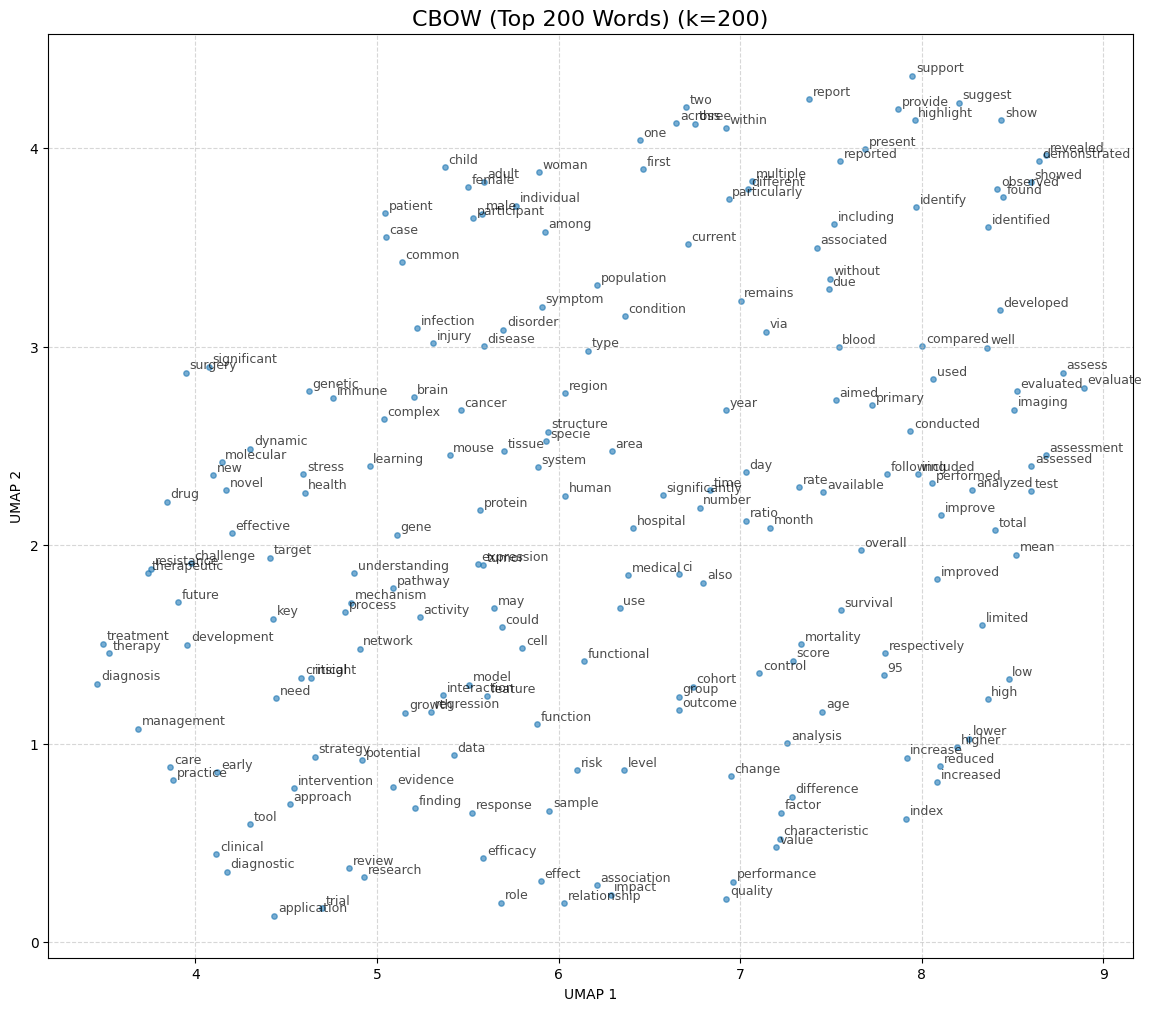

In [ ]:

print("\n" + "="*50)
print("STEP 4: CBOW 모델 고급 정성 분석 시작")
print("="*50)

# (Colab에서 이 셀만 따로 실행할 경우를 대비해 import)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from collections import defaultdict, Counter
import umap
from typing import List, Dict, Tuple

# --- 4-1. 분석용 전역 변수 ---
PAD, UNK = "<pad>", "<unk>"
SPECIALS = [PAD, UNK]

# 분석할 어휘 목록 (이곳에 정의)
TARGET_WORDS = [
    'cancer', 'patient', 'cell', 'gene', 'protein', 'dna',
    'mrna', 'disease', 'treatment', 'drug', 'therapy',
    'virus', 'covid-19', 'health', 'brain', 'blood'
]

# --- 4-2. 분석 유틸리티 함수 (공통) ---

@torch.no_grad()
def find_nearest_neighbors(query_word: str, emb_matrix: torch.Tensor,
                           stoi: Dict[str, int], itos: Dict[int, str], top_k: int = 5):
    """지정된 단어와 가장 가까운 K개 단어를 코사인 유사도 기준으로 찾기"""
    if query_word not in stoi:
        print(f"  [Error] '{query_word}'가 Vocab에 없습니다.")
        return

    query_idx = stoi[query_word]
    query_vec = emb_matrix[query_idx]

    # 코사인 유사도 계산
    emb_matrix_norm = emb_matrix / (emb_matrix.norm(dim=1, keepdim=True) + 1e-9)
    query_vec_norm = query_vec / (query_vec.norm() + 1e-9)
    cos_sim = torch.matmul(emb_matrix_norm, query_vec_norm)

    cos_sim[query_idx] = -float('inf')
    top_k_vals, top_k_indices = torch.topk(cos_sim, k=top_k)

    print(f"  ▶ Query: '{query_word}'")
    for i in range(top_k):
        word = itos[top_k_indices[i].item()]
        sim = top_k_vals[i].item()
        print(f"    {i+1}. {word} (Sim: {sim:.4f})")

def visualize_embeddings_umap(emb_matrix: np.ndarray, itos: Dict[int, str],
                              target_words: List[str], stoi: Dict[str, int], title: str):
    """UMAP으로 2D 시각화 (타겟 단어 하이라이트)"""
    print(f"\n--- [분석] {title} UMAP 시각화 (Target Words) ---")
    try:
        valid_indices = [i for i, w in itos.items() if w not in SPECIALS]
        valid_itos = {i: itos[i] for i in valid_indices}
        valid_stoi = {w: i for i, w in valid_itos.items()}
        matrix = emb_matrix[valid_indices]

        matrix_scaled = StandardScaler().fit_transform(matrix)

        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, metric='cosine')
        embedding_2d = reducer.fit_transform(matrix_scaled)

        plt.figure(figsize=(10, 8))
        plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=1, alpha=0.3, color='gray')

        for word in target_words:
            if word in valid_stoi:
                idx = list(valid_stoi.keys()).index(word)
                x, y = embedding_2d[idx, 0], embedding_2d[idx, 1]
                plt.scatter(x, y, s=50, alpha=1)
                plt.text(x+0.05, y+0.05, word, fontsize=10, fontweight='bold')

        plt.title(title, fontsize=16)
        plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2"); plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()
    except Exception as e:
        print(f"UMAP 시각화 중 오류 발생: {e}")

def run_kmeans_analysis(emb_matrix: np.ndarray, itos: Dict[int, str],
                        target_words: List[str], stoi: Dict[str, int],
                        K: int = 30, title: str = "K-Means"):
    """K-Means 군집화 분석 실행"""
    print(f"\n--- [분석] {title} K-Means 군집화 (K={K}) ---")
    try:
        valid_indices = [i for i, w in itos.items() if w not in SPECIALS]
        valid_itos_map = {i_new: itos[i_old] for i_new, i_old in enumerate(valid_indices)}
        valid_stoi_map = {w: i for i, w in valid_itos_map.items()}
        matrix = emb_matrix[valid_indices]
        matrix_scaled = StandardScaler().fit_transform(matrix)

        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(matrix_scaled)

        print(f"K-Means (K={K}) 군집화 결과 (TARGET_WORDS 위치):")
        for word in target_words:
            if word in valid_stoi_map:
                i_new = valid_stoi_map[word]
                cluster_id = cluster_labels[i_new]
                print(f"  - '{word}' \t-> Cluster {cluster_id}")
    except Exception as e:
        print(f"K-Means 분석 중 오류 발생: {e}")

@torch.no_grad()
def find_analogy(a, b, c, emb_matrix, stoi, itos, top_k=3):
    """ (b - a + c) 와 가장 유사한 단어 D를 찾기"""
    if not all(word in stoi for word in [a, b, c]):
        print(f"  [Error] '{a}', '{b}', '{c}' 중 Vocab에 없는 단어가 있습니다.")
        return
    vec_a, vec_b, vec_c = emb_matrix[stoi[a]], emb_matrix[stoi[b]], emb_matrix[stoi[c]]
    target_vec = vec_b - vec_a + vec_c

    emb_matrix_norm = emb_matrix / (emb_matrix.norm(dim=1, keepdim=True) + 1e-9)
    target_vec_norm = target_vec / (target_vec.norm() + 1e-9)
    cos_sim = torch.matmul(emb_matrix_norm, target_vec_norm)

    for word in [a, b, c]:
        if word in stoi: cos_sim[stoi[word]] = -float('inf')

    top_k_vals, top_k_indices = torch.topk(cos_sim, k=top_k)

    print(f"\n  ▶ Analogy: {b} - {a} + {c} = ?")
    for i in range(top_k):
        word = itos[top_k_indices[i].item()]
        sim = top_k_vals[i].item()
        print(f"    {i+1}. {word} (Sim: {sim:.4f})")

def visualize_top_k_words_umap(emb_matrix: torch.Tensor, itos: Dict[int, str],
                               top_k: int = 200, title: str = "UMAP (Top K Words)"):
    """상위 K개 (가장 빈번한) 단어를 UMAP으로 시각화"""
    print(f"\n--- [분석] {title} UMAP (Top {top_k} Words) ---")
    try:
        k = min(top_k, len(itos) - len(SPECIALS))
        target_indices = list(range(len(SPECIALS), len(SPECIALS) + k))
        target_words = [itos[i] for i in target_indices]
        matrix = emb_matrix.numpy()[target_indices]

        matrix_scaled = StandardScaler().fit_transform(matrix)

        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, metric='cosine')
        embedding_2d = reducer.fit_transform(matrix_scaled)

        plt.figure(figsize=(14, 12))
        plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=15, alpha=0.6)

        for i, word in enumerate(target_words):
            plt.text(embedding_2d[i, 0]+0.02, embedding_2d[i, 1]+0.02, word, fontsize=9, alpha=0.7)

        plt.title(f"{title} (k={k})", fontsize=16)
        plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2"); plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()
    except Exception as e:
        print(f"Top K UMAP 시각화 중 오류 발생: {e}")

# --- 4-3. [실행] CBOW 모델 분석 실행 ---
print("--- [CBOW] 학습 결과 분석 시작 ---")

# 1. Vocab 및 임베딩 행렬 추출
cbow_stoi = datamodule.stoi
cbow_itos = datamodule.itos
cbow_embeddings = model.emb.weight.detach().cpu()

# 2. 분석 1: 최근접 이웃 단어
print("\n" + "="*30)
print("--- [분석 1] 최근접 이웃 단어 (Cosine Similarity) ---")
print("="*30)
for word in TARGET_WORDS:
    find_nearest_neighbors(word, cbow_embeddings, cbow_stoi, cbow_itos)

# 3. 분석 2: UMAP 2D 시각화 (Target Words)
print("\n" + "="*30)
print("--- [분석 2] UMAP 2D 임베딩 시각화 (Target Words) ---")
print("="*30)
visualize_embeddings_umap(cbow_embeddings.numpy(), cbow_itos, TARGET_WORDS, cbow_stoi, "CBOW Embedding Space (UMAP)")

# 4. 분석 3: K-Means 군집화
print("\n" + "="*30)
print("--- [분석 3] K-Means 군집화 ---")
print("="*30)
run_kmeans_analysis(cbow_embeddings.numpy(), cbow_itos, TARGET_WORDS, cbow_stoi, K=30, title="CBOW")

# 5. 분석 4: 단어 유추
print("\n" + "="*30)
print("--- [분석 4] 단어 유추 (Word Analogy) ---")
print("="*30)
ANALOGY_QUERIES = [
    ('disease', 'patient', 'drug'),
    ('dna', 'gene', 'mrna'),
    ('disease', 'virus', 'health'),
    ('blood', 'cell', 'brain')
]
for a, b, c in ANALOGY_QUERIES:
    find_analogy(a, b, c, cbow_embeddings, cbow_stoi, cbow_itos)

# 6. 분석 5: Top-K UMAP
print("\n" + "="*30)
print("--- [분석 5] UMAP 2D 시각화 (Top 200 Words) ---")
print("="*30)
visualize_top_k_words_umap(cbow_embeddings, cbow_itos, top_k=200, title="CBOW (Top 200 Words)")


